In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Select the puzzle.
task_id = "50cb2852"
split = "training"

# Works whether the notebook runs from the repository root or notebook/ folder.
project_root = Path.cwd()
if not (project_root / "dataset").exists():
    project_root = project_root.parent

challenge_path = project_root / "dataset" / f"arc-agi_{split}_challenges.json"
solution_path = project_root / "dataset" / f"arc-agi_{split}_solutions.json"

with challenge_path.open() as f:
    challenges = json.load(f)

with solution_path.open() as f:
    solutions = json.load(f)

task = challenges[task_id]
test_solutions = solutions[task_id]

# Standard ARC colour palette: 0–9.
arc_colors = [
    "#000000",  # black
    "#0074D9",  # blue
    "#FF4136",  # red
    "#2ECC40",  # green
    "#FFDC00",  # yellow
    "#AAAAAA",  # grey
    "#F012BE",  # magenta
    "#FF851B",  # orange
    "#7FDBFF",  # light blue
    "#870C25",  # maroon
]
arc_cmap = ListedColormap(arc_colors)


def show_grid(ax, grid, title):
    grid = np.asarray(grid)

    ax.imshow(grid, cmap=arc_cmap, vmin=0, vmax=9)
    ax.set_title(title)

    # Draw cell boundaries.
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#555555", linewidth=0.5)

    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )


rows = len(task["train"]) + len(task["test"])
figure, axes = plt.subplots(
    rows,
    2,
    figsize=(10, max(4, rows * 4)),
    squeeze=False,
)

# Training demonstrations.
for index, example in enumerate(task["train"]):
    show_grid(axes[index, 0], example["input"], f"Train {index + 1}: input")
    show_grid(axes[index, 1], example["output"], f"Train {index + 1}: output")

# Test examples and their ground-truth answers.
offset = len(task["train"])

for index, example in enumerate(task["test"]):
    row = offset + index
    show_grid(axes[row, 0], example["input"], f"Test {index + 1}: input")
    show_grid(
        axes[row, 1],
        test_solutions[index],
        f"Test {index + 1}: correct output",
    )

figure.suptitle(f"ARC task: {task_id}", fontsize=16)
plt.tight_layout()
plt.show()

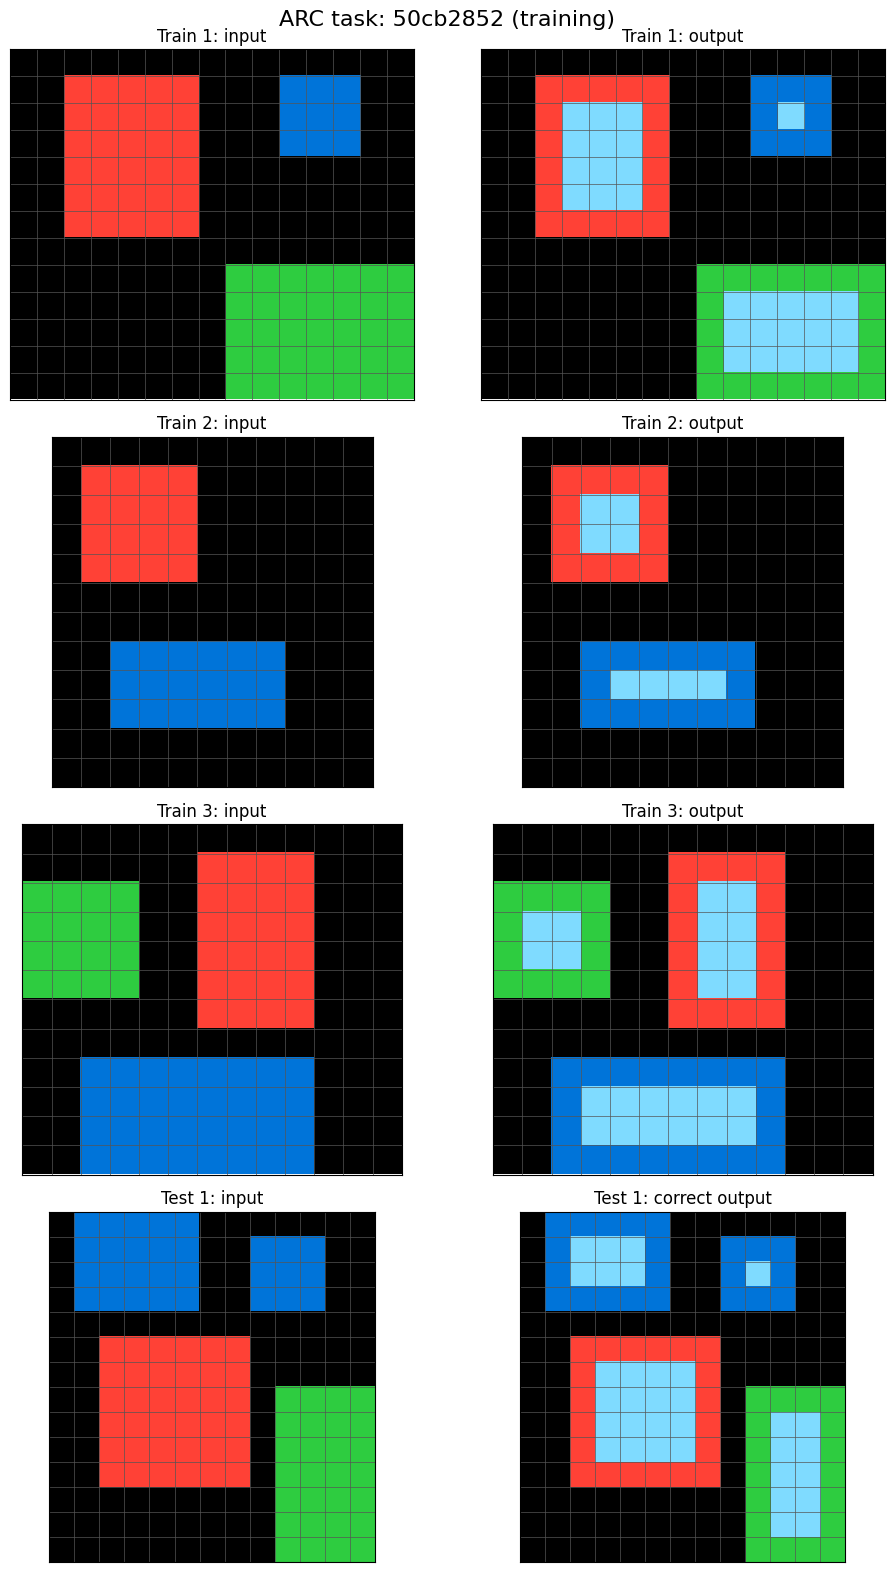

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

ARC_COLORS = [
    "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
    "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25",
]
ARC_CMAP = ListedColormap(ARC_COLORS)


def find_project_root():
    path = Path.cwd()

    for candidate in [path, *path.parents]:
        if (candidate / "dataset").exists():
            return candidate

    raise FileNotFoundError("Could not find the dataset directory.")


def draw_grid(ax, grid, title):
    grid = np.asarray(grid)

    ax.imshow(grid, cmap=ARC_CMAP, vmin=0, vmax=9)
    ax.set_title(title)

    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#555555", linewidth=0.5)

    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )


def inspect_puzzle(task_id, split="training", reveal_test_output=True):
    project_root = find_project_root()

    challenge_path = (
        project_root / "dataset" / f"arc-agi_{split}_challenges.json"
    )
    solution_path = (
        project_root / "dataset" / f"arc-agi_{split}_solutions.json"
    )

    with challenge_path.open() as file:
        challenges = json.load(file)

    if task_id not in challenges:
        possible_splits = ["training", "evaluation", "test"]
        locations = []

        for candidate_split in possible_splits:
            candidate_path = (
                project_root
                / "dataset"
                / f"arc-agi_{candidate_split}_challenges.json"
            )

            if candidate_path.exists():
                with candidate_path.open() as file:
                    candidate_tasks = json.load(file)

                if task_id in candidate_tasks:
                    locations.append(candidate_split)

        location_message = (
            f" It exists in: {', '.join(locations)}."
            if locations else ""
        )
        raise KeyError(
            f"Task {task_id!r} was not found in {split!r}.{location_message}"
        )

    task = challenges[task_id]

    test_solutions = None
    if reveal_test_output and solution_path.exists():
        with solution_path.open() as file:
            all_solutions = json.load(file)
        test_solutions = all_solutions.get(task_id)

    rows = len(task["train"]) + len(task["test"])
    figure, axes = plt.subplots(
        rows,
        2,
        figsize=(10, max(4, rows * 4)),
        squeeze=False,
    )

    for index, example in enumerate(task["train"]):
        draw_grid(
            axes[index, 0],
            example["input"],
            f"Train {index + 1}: input",
        )
        draw_grid(
            axes[index, 1],
            example["output"],
            f"Train {index + 1}: output",
        )

    offset = len(task["train"])

    for index, example in enumerate(task["test"]):
        row = offset + index

        draw_grid(
            axes[row, 0],
            example["input"],
            f"Test {index + 1}: input",
        )

        if test_solutions is not None:
            draw_grid(
                axes[row, 1],
                test_solutions[index],
                f"Test {index + 1}: correct output",
            )
        else:
            axes[row, 1].axis("off")
            axes[row, 1].set_title("Test output: hidden or unavailable")

    figure.suptitle(f"ARC task: {task_id} ({split})", fontsize=16)
    plt.tight_layout()
    plt.show()


# Specify the puzzle here:
inspect_puzzle("50cb2852", split="training")

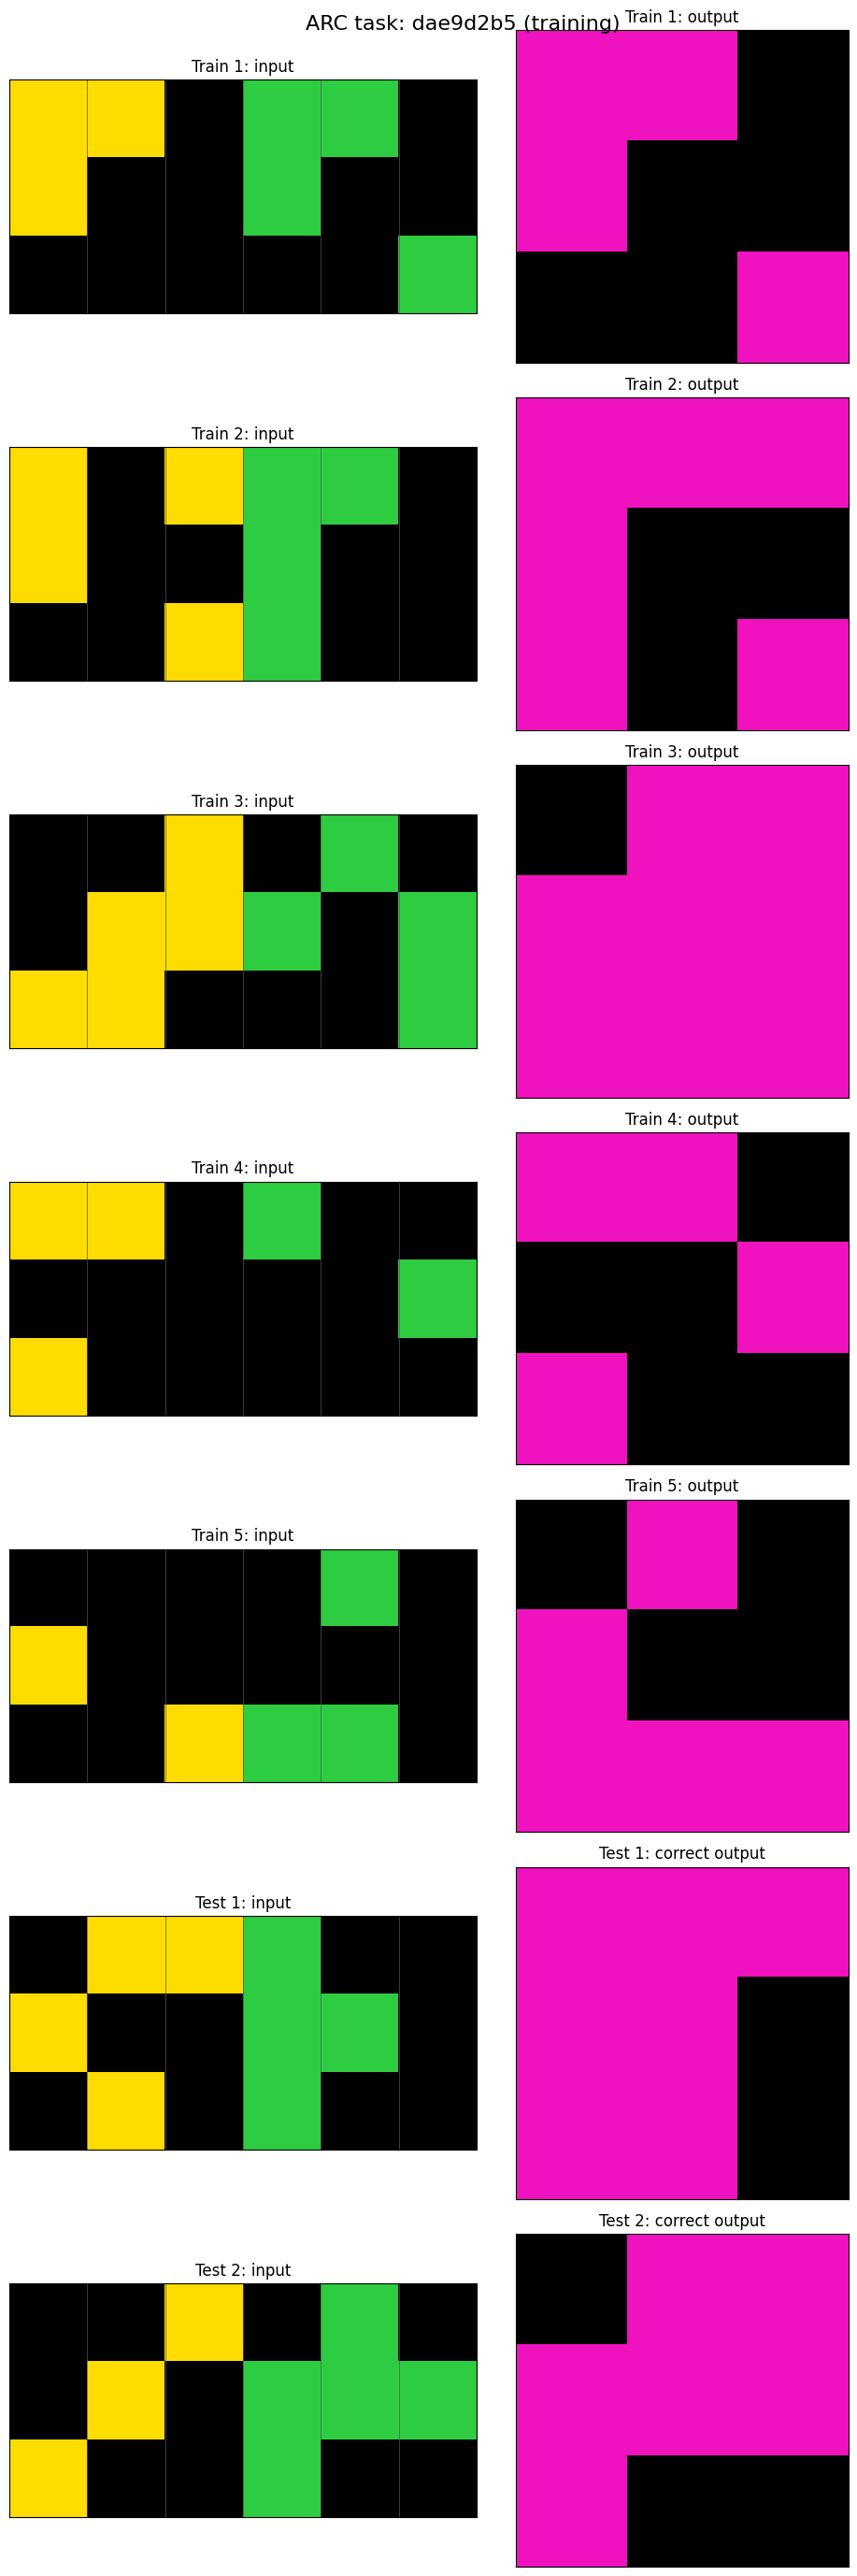

In [3]:
inspect_puzzle("dae9d2b5", split="training")

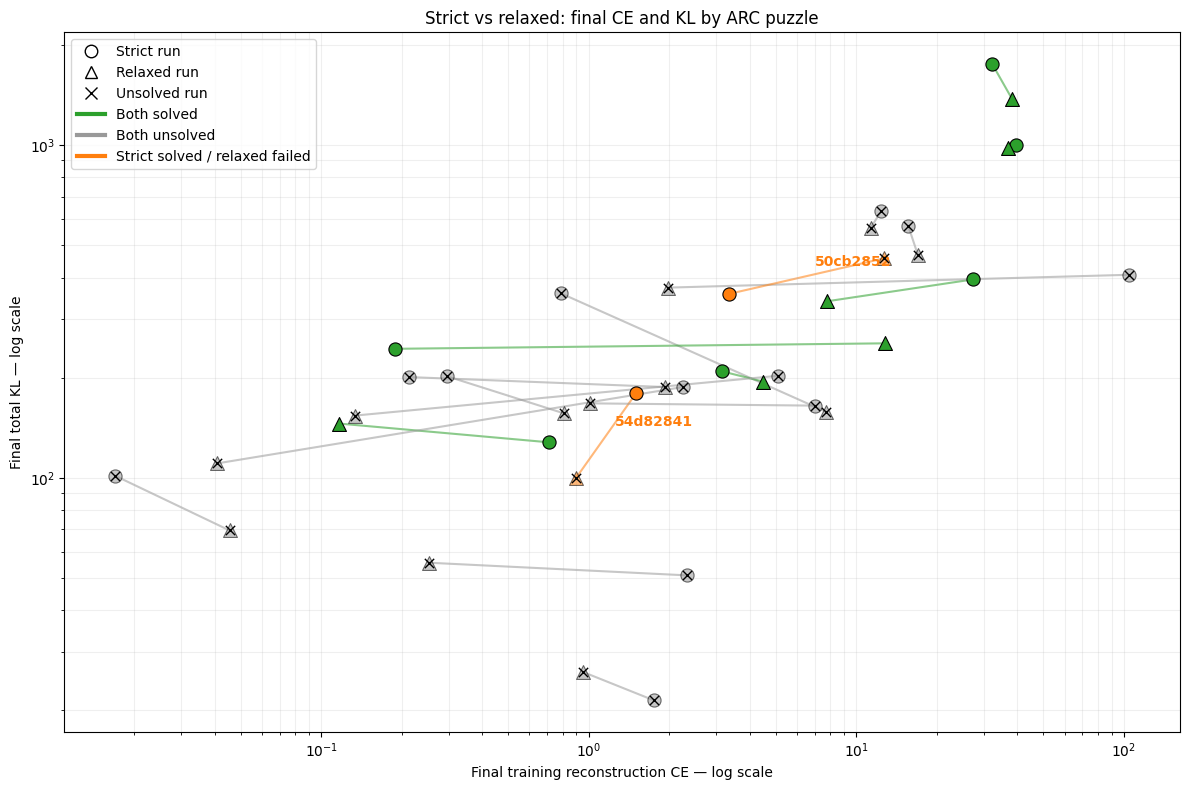

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Final values from the 40 successfully completed W&B runs.
data = [
    # task, strict_ce, strict_kl, strict_solved,
    #       relaxed_ce, relaxed_kl, relaxed_solved
    ("0a938d79", 0.7868, 358.7375, False, 7.6822, 158.2043, False),
    ("0d3d703e", 0.2960, 201.9293, False, 0.8054, 156.3976, False),
    ("0dfd9992", 39.6036, 1003.8495, True, 36.7760, 980.9161, True),
    ("22eb0ac0", 3.1472, 209.0170, True, 4.4941, 194.6638, True),
    ("239be575", 27.1812, 394.7240, True, 7.7732, 339.4539, True),
    ("25ff71a9", 2.3331, 50.9197, False, 0.2523, 55.5835, False),
    ("28e73c20", 1.7509, 21.4444, False, 0.9546, 26.0683, False),
    ("3428a4f5", 15.6270, 572.7983, False, 16.9667, 469.0629, False),
    ("4938f0c2", 0.2131, 200.8953, False, 1.9273, 187.5057, False),
    ("4be741c5", 104.7263, 407.8350, False, 1.9807, 373.1347, False),
    ("50cb2852", 3.3550, 357.4825, True, 12.7281, 457.1635, False),
    ("54d82841", 1.5069, 180.1615, True, 0.8958, 99.8098, False),
    ("623ea044", 0.7129, 127.8673, True, 0.1170, 145.6012, True),
    ("8f2ea7aa", 2.2423, 187.4523, False, 0.0409, 110.5420, False),
    ("b527c5c6", 12.3794, 633.8678, False, 11.3364, 565.0257, False),
    ("c1d99e64", 32.2187, 1752.4739, True, 38.1229, 1380.6908, True),
    ("d22278a0", 5.0824, 202.6598, False, 0.1338, 153.8861, False),
    ("dae9d2b5", 6.9966, 164.8644, False, 1.0115, 167.4840, False),
    ("ec883f72", 0.1891, 244.3110, True, 12.8361, 253.7637, True),
    ("ed36ccf7", 0.0170, 101.4487, False, 0.0455, 69.4921, False),
]

columns = [
    "task",
    "strict_ce",
    "strict_kl",
    "strict_solved",
    "relaxed_ce",
    "relaxed_kl",
    "relaxed_solved",
]
df = pd.DataFrame(data, columns=columns)


def pair_category(row):
    if row["strict_solved"] and not row["relaxed_solved"]:
        return "Strict solved / relaxed failed"
    if row["strict_solved"] and row["relaxed_solved"]:
        return "Both solved"
    if not row["strict_solved"] and not row["relaxed_solved"]:
        return "Both unsolved"
    return "Relaxed solved / strict failed"


colors = {
    "Both solved": "tab:green",
    "Both unsolved": "0.6",
    "Strict solved / relaxed failed": "tab:orange",
    "Relaxed solved / strict failed": "tab:purple",
}

df["category"] = df.apply(pair_category, axis=1)

fig, ax = plt.subplots(figsize=(12, 8))

for _, row in df.iterrows():
    color = colors[row["category"]]

    # Connect the strict and relaxed runs belonging to the same puzzle.
    ax.plot(
        [row["strict_ce"], row["relaxed_ce"]],
        [row["strict_kl"], row["relaxed_kl"]],
        color=color,
        alpha=0.55,
        linewidth=1.5,
        zorder=1,
    )

    # Strict run: circle.
    ax.scatter(
        row["strict_ce"],
        row["strict_kl"],
        marker="o",
        s=90,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=1.0 if row["strict_solved"] else 0.55,
        zorder=3,
    )

    # Relaxed run: triangle.
    ax.scatter(
        row["relaxed_ce"],
        row["relaxed_kl"],
        marker="^",
        s=100,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=1.0 if row["relaxed_solved"] else 0.55,
        zorder=3,
    )

    # Explicitly mark failed runs with an X.
    if not row["strict_solved"]:
        ax.scatter(
            row["strict_ce"],
            row["strict_kl"],
            marker="x",
            s=45,
            color="black",
            linewidth=1,
            zorder=4,
        )

    if not row["relaxed_solved"]:
        ax.scatter(
            row["relaxed_ce"],
            row["relaxed_kl"],
            marker="x",
            s=45,
            color="black",
            linewidth=1,
            zorder=4,
        )

    # Label the important strict-success/relaxed-failure cases.
    if row["category"] == "Strict solved / relaxed failed":
        midpoint_x = (row["strict_ce"] * row["relaxed_ce"]) ** 0.5
        midpoint_y = (row["strict_kl"] * row["relaxed_kl"]) ** 0.5

        ax.annotate(
            row["task"],
            (midpoint_x, midpoint_y),
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color=color,
        )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Final training reconstruction CE — log scale")
ax.set_ylabel("Final total KL — log scale")
ax.set_title("Strict vs relaxed: final CE and KL by ARC puzzle")
ax.grid(True, which="both", alpha=0.2)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="Strict run",
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="Relaxed run",
    ),
    Line2D(
        [0], [0],
        marker="x",
        linestyle="None",
        color="black",
        markersize=8,
        label="Unsolved run",
    ),
    Line2D(
        [0], [0],
        color=colors["Both solved"],
        linewidth=3,
        label="Both solved",
    ),
    Line2D(
        [0], [0],
        color=colors["Both unsolved"],
        linewidth=3,
        label="Both unsolved",
    ),
    Line2D(
        [0], [0],
        color=colors["Strict solved / relaxed failed"],
        linewidth=3,
        label="Strict solved / relaxed failed",
    ),
]

ax.legend(handles=legend_handles, loc="best", frameon=True)
plt.tight_layout()
plt.show()

# Learning Group Actions for ARC / CompressARC

## Goal

I am **not** trying to learn abstract algebra in full.

The goal is to understand enough group theory to answer:

> **Can CompressARC use a small, general transformation mechanism rather than adding separate operators for rotation, reflection, translation, etc.?**

The path is:

[
\text{transformations}
\rightarrow
\text{groups}
\rightarrow
\text{group actions}
\rightarrow
D_4
\rightarrow
\text{equivariance}
\rightarrow
\text{parameterised transformations}
\rightarrow
\text{CompressARC experiment}
]

---

# 1. Start With Transformations

Think of an ARC grid as a function

[
x : P \rightarrow C
]

where:

* (P) = positions in the grid
* (C) = colours

For a grid of height (H) and width (W),

[
P = {(r,c)\mid 0\leq r<H,;0\leq c<W}.
]

A spatial transformation changes positions:

[
\phi:P\rightarrow P.
]

Examples:

### Translation

[
(r,c)\rightarrow(r+\Delta r,c+\Delta c)
]

### Rotation

For a square grid, conceptually:

[
(r,c)\rightarrow(c,H-1-r)
]

for a (90^\circ) rotation.

### Reflection

For horizontal reflection:

[
(r,c)\rightarrow(r,W-1-c).
]

The key idea:

> Rotation, reflection and translation can all be viewed as **functions acting on coordinates**.

---

# 2. What Is a Group?

A **group** is a collection of transformations that can be combined consistently.

A set (G) with operation (\circ) is a group if it satisfies four properties.

## Closure

If

[
g_1,g_2\in G
]

then

[
g_1\circ g_2\in G.
]

Applying two valid transformations gives another valid transformation.

---

## Identity

There exists a transformation (e) that does nothing:

[
e(x)=x.
]

For rotation:

[
R_0(x)=x.
]

---

## Inverse

Every transformation can be undone.

For example:

[
R_{90}^{-1}=R_{270}.
]

Therefore:

[
R_{270}R_{90}=I.
]

---

## Associativity

[
(g_1g_2)g_3
===========

g_1(g_2g_3).
]

The order of grouping does not matter.

The **order of the transformations themselves can still matter**.

---

# 3. Composition Is the Important Part

Suppose:

[
R = \text{rotate }90^\circ
]

and

[
T = \text{translate right}.
]

Then:

[
T(R(x))
]

means:

1. rotate the object;
2. move it right.

We can write:

[
T\circ R.
]

This is important for ARC because a complicated hypothesis might be represented as:

[
h=T_3\circ T_2\circ T_1
]

instead of inventing a completely new primitive.

### Research intuition

A good computational language should allow:

[
\text{small number of primitives}
+
\text{composition}
\rightarrow
\text{large number of behaviours}.
]

---

# 4. Group Actions

A group by itself is just a set of transformations.

A **group action** specifies how those transformations operate on some object.

Let:

[
G=\text{set of transformations}
]

and

[
X=\text{set of ARC grids}.
]

A group action is:

[
G\times X\rightarrow X.
]

We can write:

[
g\cdot x.
]

Meaning:

> Apply transformation (g) to grid (x).

It must satisfy:

### Identity

[
e\cdot x=x.
]

### Composition

[
g_1\cdot(g_2\cdot x)
====================

(g_1g_2)\cdot x.
]

This second property is extremely important.

The representation respects the algebra of the transformations.

---

# 5. The Symmetries of a Square: (D_4)

ARC grids make (D_4) particularly relevant.

A square has eight symmetries.

## Rotations

[
R_0
]

[
R_{90}
]

[
R_{180}
]

[
R_{270}
]

## Reflections

There are four reflections, for example:

* horizontal
* vertical
* main diagonal
* anti-diagonal

Together these form:

[
D_4.
]

Instead of implementing:

```text
rotate90()
rotate180()
rotate270()
flipHorizontal()
flipVertical()
flipDiagonal1()
flipDiagonal2()
```

conceptually we want:

```text
transform(grid, g)
```

where:

[
g\in D_4.
]

The **mechanism is shared**.

Only the transformation parameter changes.

---

# 6. Matrix View

Coordinates can be represented as:

[
p=
\begin{bmatrix}
x\
y
\end{bmatrix}.
]

A transformation can then be written:

[
p'=Ap.
]

For example, a (90^\circ) rotation:

[
A=
\begin{bmatrix}
0 & -1\
1 & 0
\end{bmatrix}.
]

Then:

[
p'
==

\begin{bmatrix}
0 & -1\
1 & 0
\end{bmatrix}
p.
]

Reflection across one axis could be:

[
A=
\begin{bmatrix}
-1 & 0\
0 & 1
\end{bmatrix}.
]

Now rotation and reflection are no longer completely different operations.

They are different choices of:

[
A.
]

---

# 7. Add Translation

Rotation alone can be represented as:

[
p'=Ap.
]

To include translation:

[
\boxed{p'=Ap+b}
]

where:

[
b=
\begin{bmatrix}
\Delta x\
\Delta y
\end{bmatrix}.
]

Now the same mechanism can represent:

### Translation

[
A=I,\qquad b\neq0
]

### Rotation

[
A=R,\qquad b=0
]

### Rotation + translation

[
A=R,\qquad b\neq0.
]

This is already much more general than manually adding a `rotate90` primitive.

---

# 8. Composition of Transformations

Suppose:

[
T_1(p)=A_1p+b_1
]

and

[
T_2(p)=A_2p+b_2.
]

Then:

[
T_2(T_1(p))
]

becomes:

[
A_2(A_1p+b_1)+b_2
]

so:

# [

A_2A_1p+A_2b_1+b_2.
]

Therefore the composition is itself another transformation:

[
A'=A_2A_1
]

[
b'=A_2b_1+b_2.
]

This is the property I care about for ARC:

> Complex transformations can be represented as compositions of simpler transformations while remaining inside the same structured language.

---

# 9. Invariance vs Equivariance

This distinction is important.

## Invariance

[
f(gx)=f(x).
]

Changing the input using (g) does not change the output.

Example:

A classifier says:

```text
triangle
```

whether the triangle is rotated or not.

Rotation is irrelevant to the answer.

---

## Equivariance

[
\boxed{f(gx)=g f(x)}
]

Transforming the input causes the output to transform consistently.

Example:

If an ARC transformation copies an object to another position, rotating the entire puzzle should rotate both the input and predicted output.

For ARC, **equivariance is often more relevant than invariance**.

---

# 10. Why Equivariance Might Help Search

Without useful structure, a model could potentially need to learn:

```text
rule facing up
rule facing down
rule facing left
rule facing right
```

as separate hypotheses.

With rotational equivariance:

[
\text{one rule}
+
\text{orientation}
]

can represent them all.

This potentially reduces the effective hypothesis space.

Conceptually:

[
\text{less redundant hypotheses}
\rightarrow
\text{smaller search space}
\rightarrow
\text{more efficient optimisation}.
]

This directly connects to my broader research question:

> **How does computational representation affect online search efficiency?**

---

# 11. Connection to CompressARC

Current CompressARC gives the network a particular computational language:

* multitensor communication
* directional shifts
* directional communication
* reductions
* broadcasts
* nonlinearities
* etc.

My first relaxation experiment changed:

[
\text{which multitensors are allowed}
]

but mostly retained:

[
\text{the same computational primitives}.
]

Observed result:

[
\text{more connectivity}
\rightarrow
\text{lower CE in some cases}
]

but:

[
\text{more connectivity}
\not\rightarrow
\text{ability to perform rotation}.
]

Possible interpretation:

> The bottleneck may not only be representation capacity. It may be the structure of the computational language.

---

# 12. What I Do NOT Want to Do

I do not want:

```text
rotation task fails
→ add rotation operator

scaling task fails
→ add scaling operator

reflection task fails
→ add reflection operator

counting task fails
→ add counting operator
```

That risks producing:

[
\text{ARC benchmark DSL}
]

rather than learning something meaningful about general reasoning.

Instead I want:

[
\boxed{
\text{small general computational mechanism}
\rightarrow
\text{many transformations through parameterisation/composition}
}
]

---

# 13. Potential Direction

Instead of providing a dedicated rotation function, provide something like:

[
T(x;\theta)
]

where (\theta) specifies the transformation.

For spatial transformations:

[
\theta=(A,b).
]

Then:

[
T_{A,b}(x)
]

acts on the coordinates of (x).

Potentially the CompressARC latent could determine:

[
A=A(z)
]

[
b=b(z).
]

Then:

[
z
\rightarrow
(A,b)
\rightarrow
T_{A,b}(x).
]

The architecture provides the **general mechanism**.

The puzzle-specific latent specifies **which transformation to perform**.

---

# 14. Compression Interpretation

This also fits the CompressARC / MDL idea.

Instead of separately encoding:

```text
move red object right
move red object left
move red object up
move red object down
rotate red object
flip red object
```

the model might encode:

[
\text{object}
+
\text{transformation parameter}.
]

A reusable transformation language could therefore produce shorter hypotheses.

Potential research relationship:

[
\boxed{
\text{structured transformation language}
\rightarrow
\text{shorter useful hypotheses}
\rightarrow
\text{easier search}
}
]

This needs to be experimentally tested rather than assumed.

---

# 15. Questions I Should Be Able to Answer

Before implementing anything, I should be able to explain these in my own words:

* [ ] What are the four properties of a group?
* [ ] What does composition mean?
* [ ] What is a group action?
* [ ] Why is a group action different from merely having several operators?
* [ ] What transformations are contained in (D_4)?
* [ ] Why is (D_4) relevant to square ARC grids?
* [ ] What is the difference between invariance and equivariance?
* [ ] Why is equivariance more relevant than invariance for many ARC tasks?
* [ ] How can rotation be represented with a matrix (A)?
* [ ] How can translation be represented with (b)?
* [ ] Why does (p'=Ap+b) unify several spatial transformations?
* [ ] How do two transformations compose?
* [ ] Why might compositional structure reduce hypothesis-search complexity?
* [ ] Why is a general group-action mechanism different from manually adding ARC operators?

---

# 16. Small Exercises

## Exercise 1 — Composition

Take:

[
R_{90}
]

and apply it twice.

Show that:

[
R_{90}R_{90}=R_{180}.
]

---

## Exercise 2 — Inverse

Find the inverse of:

[
R_{90}.
]

Verify:

[
R_{90}^{-1}R_{90}=I.
]

---

## Exercise 3 — ARC grid

Create a simple grid:

```text
0 1 0
0 1 0
0 1 1
```

Manually calculate:

* (R_{90}(x))
* (R_{180}(x))
* horizontal reflection
* vertical reflection

---

## Exercise 4 — Composition

Take the same object.

1. Rotate it (90^\circ).
2. Translate it one cell right.

Then reverse the order:

1. Translate it right.
2. Rotate it.

Ask:

[
TR(x)\stackrel{?}{=}RT(x)
]

This shows that transformation order can matter.

---

## Exercise 5 — Equivariance

Suppose a function (f) copies an object from the left side of the grid to the right side.

Consider:

[
f(Rx)
]

and:

[
Rf(x).
]

Ask when:

[
f(Rx)=Rf(x)
]

should hold.

---

# 17. First Research Check Before Coding

Use the existing CompressARC logs.

For failed rotation tasks inspect:

* per-multitensor KL
* significant tensors
* PCA components
* CE trajectory
* KL trajectory

Question:

> Is CompressARC already spending substantial information on spatial/directional representations while still failing to form the required transformation?

If yes, that would support:

[
\text{representation contains useful spatial information}
]

but:

[
\text{computational language cannot efficiently act on it}.
]

That would provide a stronger motivation for changing the computational primitive.

---

# 18. Research Principle

Keep this constraint throughout the project:

> **Never add a primitive because one ARC puzzle needs it.**

Instead ask:

> **Does this primitive represent a general mathematical structure from which many behaviours can be composed?**

The target is:

[
\boxed{
\text{minimal primitive set}
+
\text{composition}
+
\text{parameterisation}
=======================

\text{large useful hypothesis space}
}
]

not:

[
\boxed{
\text{large hand-designed ARC operator library}.
}
]

---

# Next Topic

Once the above makes sense:

1. implement (D_4) actions on small grids by hand;
2. understand equivariant functions;
3. understand how group-equivariant neural networks encode these symmetries;
4. inspect how CompressARC currently represents directions;
5. design the smallest possible experiment introducing a **general transformation action**, not a rotation-specific operator.

